<a href="https://colab.research.google.com/github/shivkush7/Space-Anamoly-detection/blob/main/UnSupervised_Learning_in_Space_using_Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# If needed (Colab usually has them)
!pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
df = pd.read_csv("dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2123, 23)


,segment,anomaly,train,channel,sampling,duration,len,mean,var,std,...,smooth10_n_peaks,smooth20_n_peaks,diff_peaks,diff2_peaks,diff_var,diff2_var,gaps_squared,len_weighted,var_div_duration,var_div_len
0,1,1,1,CADC0872,1,279,280,8.533143e-07,3.494283e-10,0.000019,...,3,2,4,6,1.271176e-10,2.960666e-10,279,280,1.252431e-12,1.247958e-12
1,2,1,1,CADC0872,1,476,477,-3.639396e-06,6.476485e-10,0.000025,...,1,1,5,8,1.489383e-12,3.004752e-12,476,477,1.360606e-12,1.357754e-12
2,3,1,1,CADC0872,1,594,595,1.170788e-05,5.592877e-10,0.000024,...,2,2,2,3,4.112280e-12,1.029918e-11,594,595,9.415618e-13,9.399794e-13
3,4,1,1,CADC0872,1,271,272,8.486808e-07,5.466024e-10,0.000023,...,2,2,3,6,2.475760e-11,6.240985e-11,271,272,2.016983e-12,2.009568e-12
4,5,0,0,CADC0872,1,256,257,1.058485e-05,5.279023e-10,0.000023,...,1,1,78,87,5.547101e-13,7.035422e-13,256,257,2.062118e-12,2.054094e-12


In [ ]:
y = df['anomaly']
X = df.drop(['anomaly', 'channel', 'segment'], axis=1)

# Train-test split (important: keep labels aligned)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling ONLY features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Keep only NORMAL data for training
X_train_normal = X_train[y_train == 0]

print("Training only on normal samples:", X_train_normal.shape)

Training only on normal samples: (1351, 20)


In [ ]:
print(y_train.value_counts())

anomaly
0    1351
1     347
Name: count, dtype: int64


In [ ]:
input_dim = X_train.shape[1]

autoencoder = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(input_dim,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 956 (3.73 KB)

 Trainable params: 956 (3.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7719 - val_loss: 0.7715
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6753 - val_loss: 0.6903
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5837 - val_loss: 0.5852
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4589 - val_loss: 0.4693
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3740 - val_loss: 0.4016
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3199 - val_loss: 0.3419
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2749 - val_loss: 0.2942
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2357 - val_loss: 0.2589
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2056 - val_loss: 0.2303
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1823 - val_loss: 0.2082
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1639 - val_loss: 0.1931
Epoch 12/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1503 - val_lo

In [ ]:
# Train error (IMPORTANT for threshold)
train_recon = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - train_recon, 2), axis=1)

# Threshold from training data
threshold = np.percentile(train_mse, 95)
print("Threshold:", threshold)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Threshold: 0.10295167771487992


In [ ]:
# Reconstruction on test data
test_recon = autoencoder.predict(X_test)

test_mse = np.mean(np.power(X_test - test_recon, 2), axis=1)

# Predictions
y_pred = (test_mse > threshold).astype(int)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[311  27]
 [ 22  65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       338
           1       0.71      0.75      0.73        87

    accuracy                           0.88       425
   macro avg       0.82      0.83      0.83       425
weighted avg       0.89      0.88      0.89       425



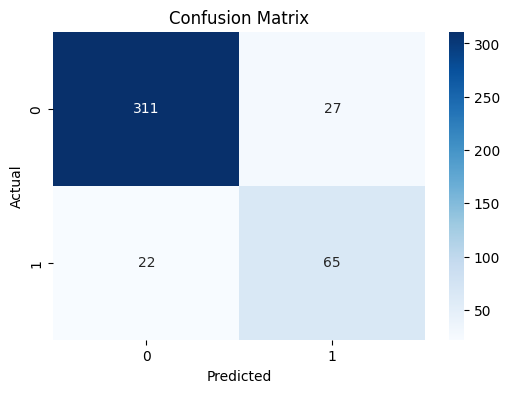

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

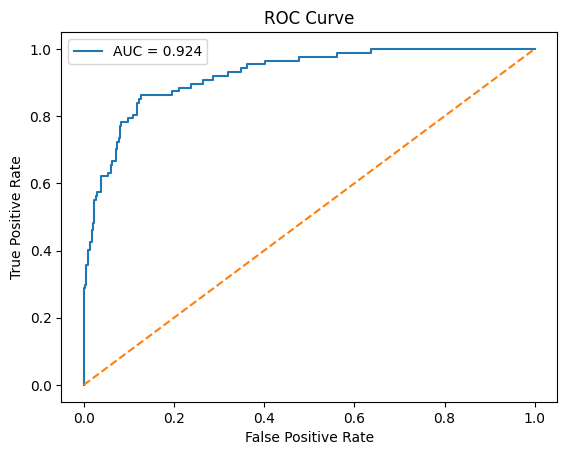

In [ ]:
fpr, tpr, _ = roc_curve(y_test, test_mse)
auc = roc_auc_score(y_test, test_mse)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
def classify_risk(error, threshold):
    if error < threshold:
        return "NORMAL"
    elif error < threshold * 1.5:
        return "WARNING"
    else:
        return "CRITICAL"

In [ ]:
def decision_system(risk_level):
    if risk_level == "NORMAL":
        return "Continue normal operation"

    elif risk_level == "WARNING":
        return "Monitor subsystem closely"

    elif risk_level == "CRITICAL":
        return "Trigger alert and corrective action"

In [ ]:
results = []

for i in range(len(test_mse)):
    error = test_mse[i]

    risk = classify_risk(error, threshold)
    action = decision_system(risk)

    results.append([error, risk, action])

In [ ]:
decision_df = pd.DataFrame(results, columns=["Error", "Risk Level", "Action"])

decision_df.head()

,Error,Risk Level,Action
0,0.019649,NORMAL,Continue normal operation
1,0.058740,NORMAL,Continue normal operation
2,0.030674,NORMAL,Continue normal operation
3,71.481553,CRITICAL,Trigger alert and corrective action
4,0.007019,NORMAL,Continue normal operation


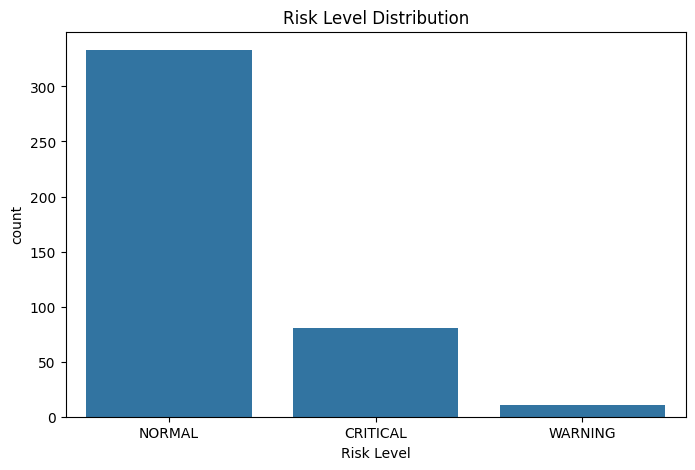

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="Risk Level", data=decision_df)
plt.title("Risk Level Distribution")
plt.show()